# 03 · Receipt-extraction pipeline

This notebook walks from raw CORD receipts to a grounded extraction pipeline, then evaluates a zero-shot VLM and a QLoRA-finetuned variant.

## Recommended run order
1. Install dependencies
2. Run the setup/import cell
3. Load CORD split metadata and inspect a few samples
4. Validate the schema + grounding helpers on a simple CPU demo
5. Run zero-shot evaluation on a frozen test slice
6. Fine-tune with QLoRA on the GPU
7. Re-run evaluation on the same frozen ids
8. Review metric tables and logs

> Notes: The notebook assumes a GPU for the VLM and training sections. If you are running on CPU, skip those sections and keep the schema, grounding, and demo pipeline cells.

**Important training constraint:** keep training vision tokens capped and use a consistent max sequence length across the model, processor, and trainer. A larger `max_length` on a T4 can produce image-token mismatches or truncated JSON output.


## 0. Setup

This section keeps installation and imports together so the notebook can start cleanly on Colab or a local GPU machine. The install step is intentionally a no-op outside Colab, and the environment checks should be the first things you run after the notebook opens.


In [2]:
# Install once. If this cell just ran for the first time: Runtime → Restart session, then run from the top.
# Do not `import unsloth` before this finishes, and do not pip-install again after Unsloth is imported.
%pip install -q unsloth datasets transformers peft trl bitsandbytes accelerate wandb pillow json-repair huggingface_hub pandas matplotlib



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 62.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 91.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 42.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.0 MB/s eta 0:00:00:00:01
   ━

In [ ]:
import hashlib
import json
import math
import os
import re
import sys
import time
from collections import defaultdict
from datetime import datetime
from io import BytesIO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Unsloth must be imported before transformers/trl/peft or it skips its patches
# and later SFTTrainer requires a formatting_func that vision collators do not use.
try:
    import unsloth  # noqa: F401
except Exception as exc:
    print("unsloth import skipped:", exc)

IN_COLAB = "google.colab" in sys.modules

os.environ.setdefault(
    "WANDB_MODE",
    "disabled" if not os.environ.get("WANDB_API_KEY") else os.environ.get("WANDB_MODE", "online"),
)

try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except Exception:
    torch = None
    HAS_GPU = False

# Inference: keep 1008 long-edge so OCR/grounding still sees small print.
# Training: cap vision tokens. Qwen2.5-VL ≈ 1 token per 28×28 pixels.
MODEL_ID = os.environ.get("MODEL_ID", "unsloth/Qwen2.5-VL-3B-Instruct-bnb-4bit")
HF_BASE_ID = os.environ.get("HF_BASE_ID", "Qwen/Qwen2.5-VL-3B-Instruct")
ADAPTER_DIR = Path(os.environ.get("ADAPTER_DIR", "outputs/lora"))
HF_ADAPTER_REPO = os.environ.get("HF_ADAPTER_REPO", "maheshnallada/vlm-receipt-extraction-lora")
LONG_EDGE = 1008
MAX_PIXELS = 1008 * 28 * 28
EVAL_MIN_PIXELS = 256 * 28 * 28
TRAIN_VISION_TOKENS = int(os.environ.get("TRAIN_VISION_TOKENS", "512"))
TRAIN_MIN_PIXELS = 128 * 28 * 28
TRAIN_MAX_PIXELS = TRAIN_VISION_TOKENS * 28 * 28
# 512 vis + prompt + compact CORD JSON. 3072 is enough for long receipts on T4
# after the eval weights are freed. Override with TRAIN_MAX_SEQ if needed.
TRAIN_MAX_SEQ = int(os.environ.get("TRAIN_MAX_SEQ", "3072"))
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.0
EVAL_N = int(os.environ.get("EVAL_N", "8"))
SANITY_TOLERANCE = 0.05
WORK = Path("pipeline_out")
WORK.mkdir(exist_ok=True)


def smart_hw(width, height, min_pixels, max_pixels, factor=28):
    """Qwen2.5-VL smart_resize: sides multiple of 28, pixels in [min, max]."""
    h = max(factor, int(round(height / factor) * factor))
    w = max(factor, int(round(width / factor) * factor))
    if h * w > max_pixels:
        scale = math.sqrt(max_pixels / max(1, height * width))
        h = max(factor, int(math.floor(height * scale / factor) * factor))
        w = max(factor, int(math.floor(width * scale / factor) * factor))
    elif h * w < min_pixels:
        scale = math.sqrt(min_pixels / max(1, height * width))
        h = max(factor, int(math.ceil(height * scale / factor) * factor))
        w = max(factor, int(math.ceil(width * scale / factor) * factor))
    return int(w), int(h)


def resize_image(image, min_pixels, max_pixels):
    from PIL import Image as PILImage

    if not isinstance(image, PILImage.Image):
        image = image.convert("RGB") if hasattr(image, "convert") else PILImage.fromarray(image).convert("RGB")
    else:
        image = image.convert("RGB")
    w, h = image.size
    nw, nh = smart_hw(w, h, min_pixels, max_pixels)
    if (nw, nh) != (w, h):
        image = image.resize((nw, nh), PILImage.Resampling.BICUBIC)
    return image


def vision_token_count(image):
    w, h = image.size
    return max(1, (h // 28) * (w // 28))


print(
    "colab", IN_COLAB, "cuda", HAS_GPU, "model", MODEL_ID,
    "train_vis", TRAIN_VISION_TOKENS, "train_max_seq", TRAIN_MAX_SEQ,
)



def _viz_ready():
    return pd is not None and plt is not None


def _show_df(df, title=None):
    if title:
        print(title)
    if pd is None:
        print(df)
        return
    try:
        display(df)
    except Exception:
        print(df.to_string(index=False))


def _style_plot():
    if plt is None:
        return
    plt.rcParams.update({
        "figure.figsize": (10, 4),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    })


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
colab False cuda True model unsloth/Qwen2.5-VL-3B-Instruct-bnb-4bit train_vis 512 train_max_seq 3072


## 0.1 Utility helpers

This block groups the shared image, display, and plotting helpers separately from the environment setup so the top of the notebook is easier to scan.


## 1. Schema, CORD mapping, JSON parse

CORD has no store-name or date labels. Those targets are `null`. Dates in the live API are ISO `YYYY-MM-DD`. Numbers are JSON numbers.


In [4]:
EXTRACT_PROMPT = (
    "Extract the receipt as JSON with keys store_name, date (YYYY-MM-DD), "
    "line_items (name, qty, unit_price, amount), subtotal, tax, total. "
    "Copy only text visible on the page. Use null when a field is absent. "
    "Numbers must be JSON numbers, not strings. Do not guess."
)

QTY_RE = re.compile(r"[-+]?\d+(?:[.,]\d+)?")
FENCE = re.compile(r"```(?:json)?\s*(.*?)```", re.DOTALL)

def parse_qty(raw):
    if raw is None:
        return None
    if isinstance(raw, (int, float)) and not isinstance(raw, bool):
        return float(raw)
    match = QTY_RE.search(str(raw))
    return float(match.group(0).replace(",", ".")) if match else None


def parse_money(raw):
    if raw is None:
        return None
    if isinstance(raw, (int, float)) and not isinstance(raw, bool):
        return float(raw)
    text = str(raw).strip().replace("Rp", "").replace("rp", "").replace(" ", "")
    if not text:
        return None
    if "," in text and "." in text:
        text = text.replace(".", "").replace(",", ".") if text.rfind(",") > text.rfind(".") else text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = "".join(parts) if len(parts[-1]) == 3 else text.replace(",", ".")
    try:
        return float(text)
    except ValueError:
        return None


def as_menu_list(menu):
    if menu is None:
        return []
    if isinstance(menu, dict):
        return [menu]
    return [item for item in menu if isinstance(item, dict)] if isinstance(menu, list) else []


"""
{
  "gt_parse": {
    "menu": [
      {"nm": "Nasi Goreng", "cnt": "1", "unitprice": "15000", "price": "15000"},
      {"nm": "Es Teh", "cnt": "2", "unitprice": "3000", "price": "6000"}
    ],
    "sub_total": {
      "subtotal_price": "21000",
      "tax_price": "2100"
    },
    "total": {
      "total_price": "23100"
    }
  }
}
"""

def cord_to_schema(gt_parse):
    items = []
    for item in as_menu_list(gt_parse.get("menu")):
        name = item.get("nm")
        if not isinstance(name, str) or not name.strip():
            continue
        items.append(
            {
                "name": name.strip(),
                "qty": parse_qty(item.get("cnt")),
                "unit_price": parse_money(item.get("unitprice")),
                "amount": parse_money(item.get("price")),
            }
        )

    raw_sub = gt_parse.get("sub_total")
    sub = raw_sub if isinstance(raw_sub, dict) else {}

    raw_tot = gt_parse.get("total")
    tot = raw_tot if isinstance(raw_tot, dict) else {}

    return {
        "store_name": None,
        "date": None,
        "line_items": items,
        "subtotal": parse_money(sub.get("subtotal_price")),
        "tax": parse_money(sub.get("tax_price")),
        "total": parse_money(tot.get("total_price")),
    }


def ground_truth_of(row):
    raw = row["ground_truth"]
    payload = json.loads(raw) if isinstance(raw, str) else raw
    return payload["gt_parse"]


def split_hash(ids):
    return hashlib.sha256(",".join(ids).encode()).hexdigest()[:16]


"""
1. Prose + JSON (most common)

Here is the receipt:
{"store_name": "Oak Cafe", "date": "2024-03-12", "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}], "subtotal": 9.0, "tax": 0.7, "total": 9.7}
Returns the {...} only. The “Here is the receipt:” line is dropped.


2. Markdown fence

```json
{"store_name": null, "date": null, "line_items": [], "subtotal": 12.0, "tax": 1.2, "total": 13.2}

`FENCE` takes the block inside ` ```json `, then the same `{` … `}` slice.

3. No object → `None`

```text
I cannot read the image.
find("{") fails, so parse raises and the notebook does the one repair generate.

"""
def extract_json_object(text):
    fenced = FENCE.search(text)
    candidate = fenced.group(1) if fenced else text
    start, end = candidate.find("{"), candidate.rfind("}")
    if start == -1 or end <= start:
        return None
    return candidate[start : end + 1]


def parse_model_output(text):
    blob = extract_json_object(text or "")
    if blob is None:
        raise ValueError("model output is not JSON")
    try:
        loaded = json.loads(blob)
    except json.JSONDecodeError:
        try:
            from json_repair import repair_json

            loaded = json.loads(repair_json(blob))
        except Exception as exc:
            raise ValueError("model output is not valid JSON") from exc
    if not isinstance(loaded, dict):
        raise ValueError("model output must be an object")
    items = []
    for item in loaded.get("line_items") or []:
        if not isinstance(item, dict) or not str(item.get("name") or "").strip():
            continue
        items.append(
            {
                "name": str(item["name"]).strip(),
                "qty": parse_qty(item.get("qty")),
                "unit_price": parse_money(item.get("unit_price")),
                "amount": parse_money(item.get("amount")),
            }
        )
    date = loaded.get("date")
    if date is not None:
        datetime.strptime(str(date), "%Y-%m-%d")
    store = loaded.get("store_name")
    return {
        "store_name": store.strip() if isinstance(store, str) and store.strip() else None,
        "date": date,
        "line_items": items,
        "subtotal": parse_money(loaded.get("subtotal")),
        "tax": parse_money(loaded.get("tax")),
        "total": parse_money(loaded.get("total")),
    }


print("schema helpers ready")

schema helpers ready


## 1.1 Schema helpers

This section keeps the conversion and JSON parsing logic together. The functions here are responsible for turning CORD gold data and model output into a clean, comparable receipt schema.


In [ ]:
# Grounding + sanity + merge helpers
# These functions decide whether a predicted field is actually on the page,
# whether totals still pass sanity checks, and how to merge multiple pages.

CURRENCY = re.compile(r"(?:[$€£¥₹]|rp\.?|idr|usd|eur|gbp)\s*", re.I)
SPACES = re.compile(r"\s+")


def normalize_text(value):
    text = CURRENCY.sub("", str(value).casefold().replace("\u00a0", " "))  # Oak&nbsp;Cafe
    return SPACES.sub(" ", text).strip()


def normalize_number_token(value):
    text = normalize_text(value).replace(" ", "")
    if not text:
        return ""
    if "," in text and "." in text:
        text = text.replace(".", "").replace(",", ".") if text.rfind(",") > text.rfind(".") else text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = "".join(parts) if len(parts[-1]) == 3 and parts[0].lstrip("-").isdigit() else text.replace(",", ".")
    return text


def parse_number(value):
    if value is None or isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        return float(value)
    token = normalize_number_token(value)
    try:
        return float(token) if token else None
    except ValueError:
        return None


def numeric_variants(value):
    if abs(value - round(value)) < 1e-9:
        whole = str(int(round(value)))
        grouped = f"{int(round(value)):,}"
        return [whole, grouped, grouped.replace(",", ".")]
    two = f"{value:.2f}"
    integer, frac = two.split(".")
    return [
        two,
        two.rstrip("0").rstrip("."),
        two.replace(".", ","),
        f"{int(integer):,}.{frac}",
        f"{int(integer):,}".replace(",", ".") + f",{frac}",
    ]


def numbers_match(predicted, document_text, tolerance=SANITY_TOLERANCE):
    hay = normalize_text(document_text)
    compact = hay.replace(",", "").replace(" ", "")
    if any(v and (v in hay or v in compact) for v in numeric_variants(predicted)):
        return True
    for token in re.findall(r"[-+]?\d[\d.,]*", document_text):
        parsed = parse_number(token)
        if parsed is not None and abs(parsed - predicted) <= tolerance:
            return True
    return False


def text_present(predicted, document_text):
    needle = normalize_text(predicted)
    hay = normalize_text(document_text)
    return bool(needle) and (needle in hay or needle.replace(" ", "") in hay.replace(" ", ""))


def date_present(iso, document_text):
    year, month, day = iso.split("-")
    month_i, day_i = int(month), int(day)
    candidates = {
        iso,
        f"{day}/{month}/{year}",
        f"{month}/{day}/{year}",
        f"{day}-{month}-{year}",
        f"{day_i}/{month_i}/{year}",
        f"{month_i}/{day_i}/{year}",
    }
    hay = normalize_text(document_text)
    return any(normalize_text(c) in hay for c in candidates)


def verification_paths(n):
    paths = ["store_name", "date"]
    for i in range(n):
        paths.extend([f"line_items.{i}.name", f"line_items.{i}.qty", f"line_items.{i}.unit_price", f"line_items.{i}.amount"])
    return paths + ["subtotal", "tax", "total"]


def _status(value, present, empty):
    if value is None:
        return None, "not_found"
    if empty:
        return None, "unverified"
    return (value, "verified") if present else (None, "not_found")


def ground_receipt(receipt, document_text):
    empty = not normalize_text(document_text)
    store, store_s = _status(receipt.get("store_name"), text_present(receipt.get("store_name") or "", document_text), empty)
    date, date_s = _status(
        receipt.get("date"),
        date_present(receipt["date"], document_text) if receipt.get("date") else False,
        empty,
    )
    items, ver = [], {"store_name": store_s, "date": date_s}
    for item in receipt.get("line_items") or []:
        name, name_s = _status(item.get("name"), text_present(item.get("name") or "", document_text), empty)
        if name is None:
            continue
        qty, qty_s = _status(item.get("qty"), numbers_match(item["qty"], document_text) if item.get("qty") is not None else False, empty)
        unit, unit_s = _status(
            item.get("unit_price"),
            numbers_match(item["unit_price"], document_text) if item.get("unit_price") is not None else False,
            empty,
        )
        amt, amt_s = _status(
            item.get("amount"),
            numbers_match(item["amount"], document_text) if item.get("amount") is not None else False,
            empty,
        )
        idx = len(items)
        items.append({"name": name, "qty": qty, "unit_price": unit, "amount": amt})
        ver[f"line_items.{idx}.name"] = name_s
        ver[f"line_items.{idx}.qty"] = qty_s
        ver[f"line_items.{idx}.unit_price"] = unit_s
        ver[f"line_items.{idx}.amount"] = amt_s
    sub, sub_s = _status(receipt.get("subtotal"), numbers_match(receipt["subtotal"], document_text) if receipt.get("subtotal") is not None else False, empty)
    tax, tax_s = _status(receipt.get("tax"), numbers_match(receipt["tax"], document_text) if receipt.get("tax") is not None else False, empty)
    tot, tot_s = _status(receipt.get("total"), numbers_match(receipt["total"], document_text) if receipt.get("total") is not None else False, empty)
    ver.update({"subtotal": sub_s, "tax": tax_s, "total": tot_s})
    return {"store_name": store, "date": date, "line_items": items, "subtotal": sub, "tax": tax, "total": tot, "_verification": ver}


def check_totals(receipt, tolerance=SANITY_TOLERANCE):
    ver = dict(receipt.get("_verification") or {})
    amounts = [item["amount"] for item in receipt.get("line_items") or [] if item.get("amount") is not None]
    items_total = sum(amounts) if amounts else None
    sub, tax, tot = receipt.get("subtotal"), receipt.get("tax"), receipt.get("total")
    if items_total is not None and sub is not None and abs(items_total - sub) > tolerance:
        ver["subtotal"] = "unverified"
        for i, item in enumerate(receipt.get("line_items") or []):
            if item.get("amount") is not None:
                ver[f"line_items.{i}.amount"] = "unverified"
    if sub is not None and tot is not None and abs(sub + (tax or 0.0) - tot) > tolerance:
        ver["subtotal"] = ver["total"] = "unverified"
        if tax is not None:
            ver["tax"] = "unverified"
    out = dict(receipt)
    out["_verification"] = ver
    return out


def page_score(receipt, fields):
    ver = receipt.get("_verification") or {}
    return sum(1 for f in fields if ver.get(f) == "verified")


def merge_pages(pages):
    if not pages:
        return {"store_name": None, "date": None, "line_items": [], "subtotal": None, "tax": None, "total": None,
                "_verification": {k: "not_found" for k in verification_paths(0)}}
    if len(pages) == 1:
        return pages[0]
    items, item_ver = [], {}
    for page in pages:
        offset = len(items)
        items.extend(page.get("line_items") or [])
        for i, _ in enumerate(page.get("line_items") or []):
            for leaf in ("name", "qty", "unit_price", "amount"):
                item_ver[f"line_items.{offset + i}.{leaf}"] = page["_verification"][f"line_items.{i}.{leaf}"]
    header = max(enumerate(pages), key=lambda row: (page_score(row[1], ("store_name", "date")), -row[0]))[1]
    money = max(enumerate(pages), key=lambda row: (page_score(row[1], ("subtotal", "tax", "total")), row[0]))[1]
    ver = {**item_ver, "store_name": header["_verification"]["store_name"], "date": header["_verification"]["date"],
           "subtotal": money["_verification"]["subtotal"], "tax": money["_verification"]["tax"], "total": money["_verification"]["total"]}
    for path in verification_paths(len(items)):
        ver.setdefault(path, "not_found")
    return {"store_name": header.get("store_name"), "date": header.get("date"), "line_items": items,
            "subtotal": money.get("subtotal"), "tax": money.get("tax"), "total": money.get("total"), "_verification": ver}


print("ground / sanity / merge ready")


ground / sanity / merge ready


### 2.2 Numeric boundary guard

This small validation block hardens the grounding logic so a number must match as its own token rather than being accidentally found inside a larger numeric string.


In [ ]:
# Match complete numeric tokens so a value cannot be grounded inside a larger number.
def numbers_match(predicted, document_text, tolerance=SANITY_TOLERANCE):
    haystack = normalize_text(document_text)
    for variant in numeric_variants(predicted):
        if not variant:
            continue
        pattern = rf"(?<![\w.,+-]){re.escape(variant)}(?![\w.,+-])"
        if re.search(pattern, haystack):
            return True
    for token in re.findall(r"[-+]?\d[\d.,]*", document_text):
        parsed = parse_number(token)
        if parsed is not None and abs(parsed - predicted) <= tolerance:
            return True
    return False


assert numbers_match(12.0, "TOTAL 12.00")
assert not numbers_match(12.0, "unrelated amount 112.00")
print("numeric grounding boundary checks passed")


## 3. Extract pipeline

One function: raw model text per page → parse (one repair retry) → ground per page → merge → ground on full text → sanity.


In [6]:
def empty_receipt():
    return {
        "store_name": None,
        "date": None,
        "line_items": [],
        "subtotal": None,
        "tax": None,
        "total": None,
        "_verification": {k: "not_found" for k in verification_paths(0)},
    }


def extract_one_page(raw_text, repair_text=None):
    try:
        return parse_model_output(raw_text)
    except ValueError:
        if repair_text is None:
            raise
        try:
            return parse_model_output(repair_text)
        except ValueError:
            return empty_receipt()


def run_pipeline(page_outputs):
    # page_outputs: list of {raw, text, repair?}
    grounded_pages = []
    before = []
    for page in page_outputs:
        try:
            parsed = extract_one_page(page["raw"], page.get("repair"))
        except ValueError:
            parsed = empty_receipt()
        before.append(json.loads(json.dumps(parsed)))
        grounded_pages.append(ground_receipt(parsed, page.get("text") or ""))
    merged = merge_pages(grounded_pages)
    combined = "\n".join(page.get("text") or "" for page in page_outputs)
    grounded = ground_receipt(merged, combined)
    return check_totals(grounded), before, combined


print("pipeline ready")


pipeline ready


## 4. CPU demo (no model)

A clerk-style receipt as text. The dummy “model” emits JSON (and one broken JSON to show repair). The pipeline must still return schema-valid output.


In [7]:
PAGE_TEXT = '''Oak & Ember Cafe
15/03/2026
Latte  2 x 4.50  9.00
Croissant  1 x 3.50  3.50
SUBTOTAL 12.50
TAX 1.00
TOTAL 13.50
'''

good = json.dumps({
    "store_name": "Oak & Ember Cafe",
    "date": "2026-03-15",
    "line_items": [
        {"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0},
        {"name": "Croissant", "qty": 1, "unit_price": 3.5, "amount": 3.5},
    ],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 13.5,
})
hallucinated = json.dumps({
    "store_name": "Totally Fake Shop",
    "date": "2026-03-15",
    "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 99.0,
})

ok, _, _ = run_pipeline([{"raw": good, "text": PAGE_TEXT}])
print("clean extract")
print(json.dumps(ok, indent=2))

broken, _, _ = run_pipeline([{"raw": "{not json", "repair": good, "text": PAGE_TEXT}])
print("after one repair, store =", broken["store_name"])

ghost, before, _ = run_pipeline([{"raw": hallucinated, "text": PAGE_TEXT}])
print("hallucinated store before grounding:", before[0]["store_name"])
print("after grounding:", ghost["store_name"], ghost["_verification"]["store_name"])
print("hallucinated total 99 nulled (not on the page):", ghost["total"], ghost["_verification"]["total"])

# Sanity: every number is on the page, but subtotal + tax != total.
mismatch = json.dumps({
    "store_name": "Oak & Ember Cafe",
    "date": "2026-03-15",
    "line_items": [{"name": "Latte", "qty": 2, "unit_price": 4.5, "amount": 9.0}],
    "subtotal": 12.5,
    "tax": 1.0,
    "total": 12.5,
})
checked, _, _ = run_pipeline([{"raw": mismatch, "text": PAGE_TEXT}])
print("sanity fail keeps 12.5 (it is on the page) as", checked["_verification"]["total"], "total=", checked["total"])


clean extract
{
  "store_name": "Oak & Ember Cafe",
  "date": "2026-03-15",
  "line_items": [
    {
      "name": "Latte",
      "qty": 2.0,
      "unit_price": 4.5,
      "amount": 9.0
    },
    {
      "name": "Croissant",
      "qty": 1.0,
      "unit_price": 3.5,
      "amount": 3.5
    }
  ],
  "subtotal": 12.5,
  "tax": 1.0,
  "total": 13.5,
  "_verification": {
    "store_name": "verified",
    "date": "verified",
    "line_items.0.name": "verified",
    "line_items.0.qty": "verified",
    "line_items.0.unit_price": "verified",
    "line_items.0.amount": "verified",
    "line_items.1.name": "verified",
    "line_items.1.qty": "verified",
    "line_items.1.unit_price": "verified",
    "line_items.1.amount": "verified",
    "subtotal": "verified",
    "tax": "verified",
    "total": "verified"
  }
}
after one repair, store = Oak & Ember Cafe
hallucinated store before grounding: Totally Fake Shop
after grounding: None not_found
hallucinated total 99 nulled (not on the page): None 

## 5. Metrics (used for zero-shot and fine-tuned)


In [8]:
def values_equal(left, right):
    if left is None or right is None:
        return left is None and right is None
    if isinstance(left, str) or isinstance(right, str):
        return normalize_text(str(left)) == normalize_text(str(right))
    try:
        return abs(float(left) - float(right)) <= SANITY_TOLERANCE
    except (TypeError, ValueError):
        return left == right


def prf(tp, fp, fn, exact, n):
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "exact_match": exact / n if n else 0.0}


def field_scores(golds, preds, field):
    tp = fp = fn = exact = 0
    for gold, pred in zip(golds, preds):
        gv, pv = gold.get(field), pred.get(field)
        if gv is None and pv is None:
            exact += 1
        elif gv is None:
            fp += 1
        elif pv is None:
            fn += 1
        elif values_equal(gv, pv):
            tp += 1
            exact += 1
        else:
            fp += 1
            fn += 1
    return prf(tp, fp, fn, exact, len(golds))


def line_item_scores(golds, preds):
    totals = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0, "exact": 0, "n": 0})
    for gold, pred in zip(golds, preds):
        remaining = list(pred.get("line_items") or [])
        pairs = []
        for item in gold.get("line_items") or []:
            hit = None
            for i, cand in enumerate(remaining):
                if normalize_text(cand.get("name") or "") == normalize_text(item.get("name") or ""):
                    hit = remaining.pop(i)
                    break
            pairs.append((item, hit))
        pairs.extend((None, extra) for extra in remaining)
        for g_item, p_item in pairs:
            for leaf in ("name", "qty", "unit_price", "amount"):
                b = totals[leaf]
                b["n"] += 1
                gv = None if g_item is None else g_item.get(leaf)
                pv = None if p_item is None else p_item.get(leaf)
                if gv is None and pv is None:
                    b["exact"] += 1
                elif gv is None:
                    b["fp"] += 1
                elif pv is None:
                    b["fn"] += 1
                elif values_equal(gv, pv):
                    b["tp"] += 1
                    b["exact"] += 1
                else:
                    b["fp"] += 1
                    b["fn"] += 1
    return {leaf: prf(v["tp"], v["fp"], v["fn"], v["exact"], v["n"]) for leaf, v in totals.items()}


def exact_receipt(gold, pred):
    if any(not values_equal(gold.get(f), pred.get(f)) for f in ("store_name", "date", "subtotal", "tax", "total")):
        return False
    g = sorted(gold.get("line_items") or [], key=lambda i: normalize_text(i.get("name") or ""))
    p = sorted(pred.get("line_items") or [], key=lambda i: normalize_text(i.get("name") or ""))
    if len(g) != len(p):
        return False
    return all(values_equal(a.get(k), b.get(k)) for a, b in zip(g, p) for k in ("name", "qty", "unit_price", "amount"))


def hallucination_rate(preds, texts):
    missing = non_null = 0
    for pred, text in zip(preds, texts):
        values = [pred.get("store_name"), pred.get("date"), pred.get("subtotal"), pred.get("tax"), pred.get("total")]
        for item in pred.get("line_items") or []:
            values.extend([item.get("name"), item.get("qty"), item.get("unit_price"), item.get("amount")])
        for value in values:
            if value is None:
                continue
            non_null += 1
            if isinstance(value, str) and not text_present(value, text):
                missing += 1
            elif isinstance(value, (int, float)) and not numbers_match(float(value), text):
                missing += 1
    return 0.0 if not non_null else missing / non_null


def latency_percentiles(samples_ms):
    if not samples_ms:
        return {"p50": None, "p95": None}
    ordered = sorted(samples_ms)

    def pct(p):
        return ordered[min(len(ordered) - 1, max(0, int(round((p / 100) * (len(ordered) - 1)))))]

    return {"p50": pct(50), "p95": pct(95)}


def summarize(golds, preds, texts, latencies, stage):
    fields = {name: field_scores(golds, preds, name) for name in ("store_name", "date", "subtotal", "tax", "total")}
    fields["line_items"] = line_item_scores(golds, preds)
    exact = sum(exact_receipt(g, p) for g, p in zip(golds, preds)) / max(1, len(golds))
    peak = "n/a"
    if HAS_GPU and torch is not None:
        peak = f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
    return {
        "stage": stage,
        "n": len(golds),
        "fields": fields,
        "exact_match_receipt": exact,
        "json_validity": 1.0,
        "hallucination_after_grounding": hallucination_rate(preds, texts),
        "latency_ms_per_page": latency_percentiles(latencies),
        "peak_gpu_memory": peak,
    }


def stage_frame(stage):
    rows = []
    for name, scores in stage["fields"].items():
        if name == "line_items":
            for leaf, s in scores.items():
                rows.append({"field": f"line_items.{leaf}", **s})
        else:
            rows.append({"field": name, **scores})
    if pd is None:
        return rows
    return pd.DataFrame(rows)[["field", "precision", "recall", "f1", "exact_match"]]


def show_table(stage):
    lat = stage["latency_ms_per_page"]
    print(
        f"{stage['stage']}  n={stage['n']}  receipt_exact={stage['exact_match_receipt']:.3f}  "
        f"hallu={stage['hallucination_after_grounding']:.3f}  "
        f"latency_ms p50/p95={lat['p50']}/{lat['p95']}  gpu={stage['peak_gpu_memory']}"
    )
    frame = stage_frame(stage)
    if pd is None:
        print(frame)
        return
    _show_df(frame.round(3), None)
    if plt is None or frame.empty:
        return
    _style_plot()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    x = range(len(frame))
    axes[0].bar([i - 0.2 for i in x], frame["f1"], width=0.4, label="F1")
    axes[0].bar([i + 0.2 for i in x], frame["exact_match"], width=0.4, label="Exact")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(frame["field"], rotation=35, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("score")
    axes[0].set_title(f"{stage['stage']} field F1 vs Exact (n={stage['n']})")
    axes[0].legend()
    axes[1].bar(["p50", "p95"], [lat["p50"] or 0, lat["p95"] or 0], color=["#4C78A8", "#F58518"])
    axes[1].set_ylabel("ms / page")
    axes[1].set_title(f"{stage['stage']} extract latency")
    fig.tight_layout()
    plt.show()


print("metrics ready")


metrics ready


## 6. CORD v2 — official splits, frozen ids

Test ids are never used for training. If `datasets` is missing, this cell skips.


In [12]:
dataset = None
splits = {"train": [], "validation": [], "test": []}
try:
    
    from datasets import load_dataset

    dataset = load_dataset("naver-clova-ix/cord-v2")
    for name in dataset:
        ids = []
        for index, row in enumerate(dataset[name]):
            gt = json.loads(row["ground_truth"]) if isinstance(row["ground_truth"], str) else row["ground_truth"]
            ids.append(str((gt.get("meta") or {}).get("image_id", f"{name}-{index}")))
        splits[name] = ids
    (WORK / "splits.json").write_text(
        json.dumps({"splits": splits, "hash": {k: split_hash(v) for k, v in splits.items()}}, indent=2),
        encoding="utf-8",
    )
    print({k: len(v) for k, v in splits.items()})
    print(json.dumps(cord_to_schema(ground_truth_of(dataset["train"][0])), indent=2)[:600])
except Exception as exc:
    print("CORD not loaded (install datasets or run on Colab):", exc)


{'train': 800, 'validation': 100, 'test': 100}
{
  "store_name": null,
  "date": null,
  "line_items": [
    {
      "name": "Nasi Campur Bali",
      "qty": 1.0,
      "unit_price": null,
      "amount": 75000.0
    },
    {
      "name": "Bbk Bengil Nasi",
      "qty": 1.0,
      "unit_price": null,
      "amount": 125000.0
    },
    {
      "name": "MilkShake Starwb",
      "qty": 1.0,
      "unit_price": null,
      "amount": 37000.0
    },
    {
      "name": "Ice Lemon Tea",
      "qty": 1.0,
      "unit_price": null,
      "amount": 24000.0
    },
    {
      "name": "Nasi Ayam Dewata",
      "qty": 1.0,
      "unit_price": null,
 


## 6b. Inspect random CORD training samples

This section gives you a quick visual sanity check on the official train split before fine-tuning. It shows a few sample receipts and the corresponding schema fields, without touching the frozen test ids.


showing 3 of 800 official train receipts  ids=[286, 227, 690]

--- train[286]  1/3  size=(576, 864) ---


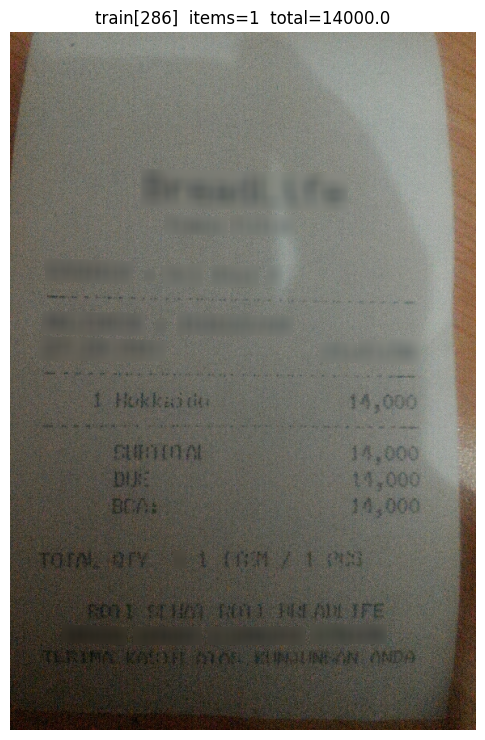

,name,qty,unit_price,amount
0,Hokkaido,1.0,None,14000.0


{
  "store_name": null,
  "date": null,
  "subtotal": 14.0,
  "tax": null,
  "total": 14000.0
}

--- train[227]  2/3  size=(432, 648) ---


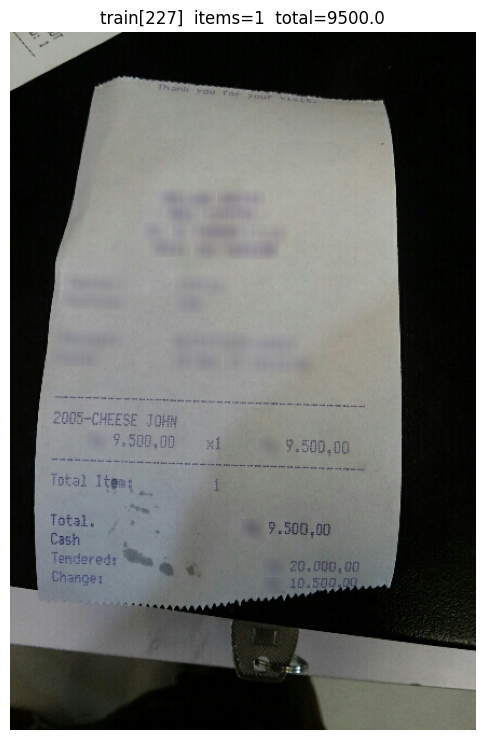

,name,qty,unit_price,amount
0,2005-CHEESE JOHN,1.0,9500.0,9500.0


{
  "store_name": null,
  "date": null,
  "subtotal": null,
  "tax": null,
  "total": 9500.0
}

--- train[690]  3/3  size=(2304, 4096) ---


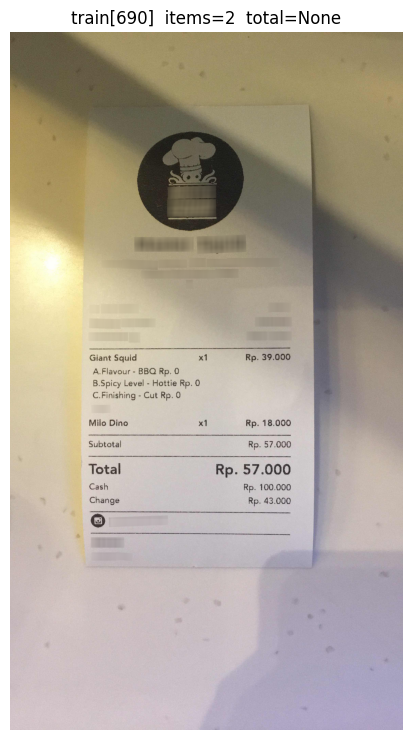

,name,qty,unit_price,amount
0,Giant Squid,1.0,None,None
1,Milo Dino,1.0,None,None


{
  "store_name": null,
  "date": null,
  "subtotal": null,
  "tax": null,
  "total": null
}


In [13]:
import random

PREVIEW_N = int(os.environ.get("PREVIEW_N", "3"))


def show_random_train_samples(n=PREVIEW_N, seed=None):
    if dataset is None:
        print("CORD not loaded — run the split cell first")
        return
    split = dataset["train"]
    n = min(n, len(split))
    rng = random.Random(seed)
    idxs = rng.sample(range(len(split)), n)
    print(f"showing {n} of {len(split)} official train receipts  ids={idxs}")
    for rank, idx in enumerate(idxs, 1):
        row = split[idx]
        gold = cord_to_schema(ground_truth_of(row))
        image = row["image"]
        if hasattr(image, "convert"):
            image = image.convert("RGB")
        print(f"\n--- train[{idx}]  {rank}/{n}  size={getattr(image, 'size', None)} ---")
        if plt is not None:
            fig, ax = plt.subplots(figsize=(5.5, 7.5))
            ax.imshow(image)
            ax.set_title(f"train[{idx}]  items={len(gold['line_items'])}  total={gold['total']}")
            ax.axis("off")
            fig.tight_layout()
            plt.show()
        else:
            display(image)
        items = gold.get("line_items") or []
        if pd is not None and items:
            _show_df(pd.DataFrame(items), None)
        header = {k: gold[k] for k in ("store_name", "date", "subtotal", "tax", "total")}
        print(json.dumps(header, indent=2))
        if not items:
            print(json.dumps(gold, indent=2))


show_random_train_samples()


In [ ]:
# Conservative default after the prior T4 run produced non-finite losses.
# Set TRAIN_LR before running this notebook to override it.
os.environ.setdefault("TRAIN_LR", "1e-5")
print("training learning rate", os.environ["TRAIN_LR"])


In [14]:


def wandb_init(extra=None):
    if os.environ.get("WANDB_MODE") == "disabled" or not os.environ.get("WANDB_API_KEY"):
        print("wandb disabled")
        return None
    try:
        import wandb

        cfg = {
            "model_id": MODEL_ID,
            "lora_r": LORA_R,
            "lora_alpha": LORA_ALPHA,
            "lora_dropout": LORA_DROPOUT,
            "bits": 4,
            "image_resolution": LONG_EDGE,
            "learning_rate": float(os.environ.get("TRAIN_LR", "5e-5")),
            "train_size": len(splits.get("train", [])),
            "val_size": len(splits.get("validation", [])),
            "split_hash": {k: split_hash(v) for k, v in splits.items() if v},
        }
        if extra:
            cfg.update(extra)
        return wandb.init(project=os.environ.get("WANDB_PROJECT", "vlm-receipt-extraction"), config=cfg)
    except Exception as exc:
        print("wandb skipped", exc)
        return None


wb = wandb_init()


wandb disabled


## 7. VLM load + one-page infer (needs GPU)

Skip on CPU. Temperature 0. One repair generation if JSON/schema fails.


In [15]:
vlm = {"model": None, "processor": None}


def load_vlm(adapter_path=None):
    if not HAS_GPU:
        print("no GPU — skip VLM load")
        return
    from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration

    base = HF_BASE_ID
    processor = AutoProcessor.from_pretrained(base, min_pixels=EVAL_MIN_PIXELS, max_pixels=MAX_PIXELS)
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        base, quantization_config=quant, device_map="auto", torch_dtype=torch.float16
    )
    if adapter_path and Path(adapter_path).exists():
        from peft import PeftModel

        model = PeftModel.from_pretrained(model, adapter_path)
    model.eval()
    # Qwen generation_config still carries temperature; greedy decode warns otherwise.
    if getattr(model, "generation_config", None) is not None:
        model.generation_config.temperature = None
        model.generation_config.top_p = None
        model.generation_config.top_k = None
    vlm["model"], vlm["processor"] = model, processor
    print("loaded", base, "adapter", adapter_path or "base")


def free_vlm():
    import gc

    vlm["model"] = None
    vlm["processor"] = None
    gc.collect()
    if HAS_GPU and torch is not None:
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        torch.cuda.reset_peak_memory_stats()
    print("freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)")


def infer_page(image, repair_hint=None):
    if vlm["model"] is None:
        raise RuntimeError("model not loaded")
    image = resize_image(image, EVAL_MIN_PIXELS, MAX_PIXELS)
    prompt = EXTRACT_PROMPT if not repair_hint else f"Previous output failed: {repair_hint}\n{EXTRACT_PROMPT}"
    messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}]}]
    text = vlm["processor"].apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = vlm["processor"](text=[text], images=[image], padding=True, return_tensors="pt")
    inputs = inputs.to(vlm["model"].device)
    out = vlm["model"].generate(**inputs, max_new_tokens=1024, do_sample=False)
    trimmed = out[:, inputs["input_ids"].shape[1] :]
    return vlm["processor"].batch_decode(trimmed, skip_special_tokens=True)[0]


def extract_image(image, page_text=""):
    raw = infer_page(image)
    repair = None
    try:
        parse_model_output(raw)
    except ValueError as exc:
        repair = infer_page(image, repair_hint=str(exc))
    result, before, _ = run_pipeline([{"raw": raw, "repair": repair, "text": page_text}])
    return result, raw, before[0]


if HAS_GPU:
    load_vlm()
else:
    print("CPU: VLM cells below will no-op")



preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter base


## 8. Zero-shot eval on a frozen test slice

Same ids will be reused after fine-tuning. `EVAL_N` defaults to 8 on a T4. After this cell, `free_vlm()` must run so QLoRA can load.

CORD gold `store_name` / `date` are always null. F1 0 with high Exact means the model also emitted null (or grounding wiped a guess).


eval rows 8


/usr/local/lib/python3.12/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.12/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.12/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.12/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


zero-shot  n=8  receipt_exact=0.000  hallu=0.000  latency_ms p50/p95=19031.025934000012/181904.865773  gpu=1.21 GiB


,field,precision,recall,f1,exact_match
0,store_name,0.000,0.000,0.000,0.625
1,date,0.000,0.000,0.000,1.000
2,subtotal,0.714,0.833,0.769,0.625
3,tax,1.000,1.000,1.000,1.000
4,total,1.000,0.875,0.933,0.875
5,line_items.name,0.545,0.429,0.480,0.316
6,line_items.qty,0.273,0.333,0.300,0.263
7,line_items.unit_price,0.000,0.000,0.000,0.474
8,line_items.amount,0.600,0.429,0.500,0.368


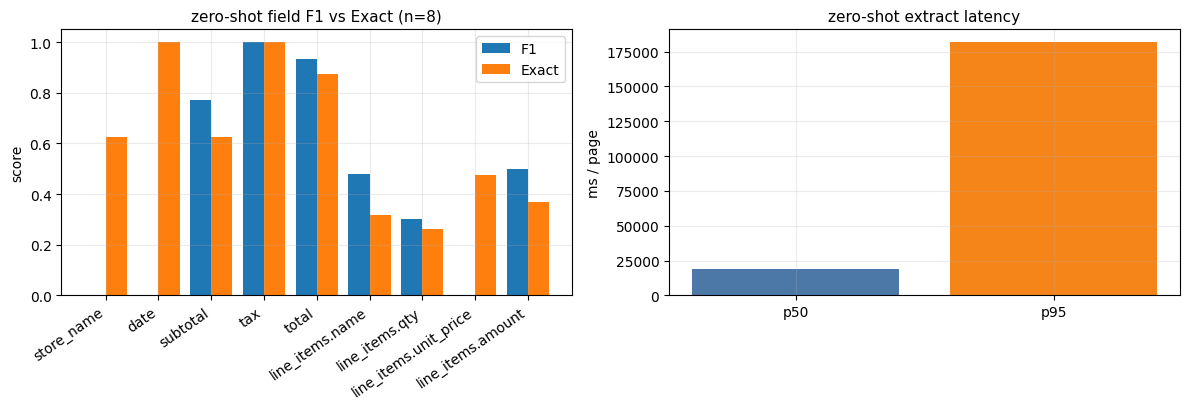

freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


In [16]:
def cord_page_text(row):
    raw = row["ground_truth"]
    payload = json.loads(raw) if isinstance(raw, str) else raw
    lines = []
    for line in payload.get("valid_line") or []:
        words = [w.get("text", "") for w in line.get("words") or []]
        if words:
            lines.append(" ".join(words))
    return "\n".join(lines)


def cord_eval_rows(n=EVAL_N):
    if dataset is None:
        return []
    rows = []
    for row in dataset["test"]:
        gold = cord_to_schema(ground_truth_of(row))
        rows.append({"image": row["image"], "gold": gold, "text": cord_page_text(row)})
        if len(rows) >= n:
            break
    return rows


def eval_vlm(rows, stage):
    golds, preds, texts, latencies = [], [], [], []
    if vlm["model"] is None:
        print("no model — skip", stage)
        return None
    if HAS_GPU:
        torch.cuda.reset_peak_memory_stats()
    for row in rows:
        started = time.perf_counter()
        result, raw, _ = extract_image(row["image"], row.get("text") or "")
        latencies.append((time.perf_counter() - started) * 1000.0)
        pred = {k: result[k] for k in ("store_name", "date", "line_items", "subtotal", "tax", "total")}
        golds.append(row["gold"])
        preds.append(pred)
        texts.append(row.get("text") or "")
        del raw
    summary = summarize(golds, preds, texts, latencies, stage)
    show_table(summary)
    return summary


eval_rows = cord_eval_rows()
print("eval rows", len(eval_rows))
zero_shot = eval_vlm(eval_rows, "zero-shot") if eval_rows and HAS_GPU else None
if HAS_GPU:
    free_vlm()



## 9. QLoRA fine-tune (needs GPU)

Language / attention / MLP only — no vision-encoder LoRA (T4 headroom).

**Truncation vs OOM:** cutting `max_length` while leaving full-resolution CORD images
makes Unsloth tokenize ~1000 image tokens + prompt + JSON, then the trainer truncates
the *tail*. That tail is the assistant JSON (labels become `-100` / empty → NaN) or
the image placeholders (Unsloth: image-token mismatch). Do **not** jump to 8192 either:
attention memory is O(seq²) and a second 3B still on GPU OOMs the T4.

This cell shrinks **training images** to `TRAIN_VISION_TOKENS` (default 512), keeps
`TRAIN_MAX_SEQ=3072` for long receipts, sets that length on the model + collator +
`SFTConfig`, and drops leftovers that still do not fit. `MAX_TRAIN=200` is the T4
smoke default; set `MAX_TRAIN=0` for the full official train split.

If loss drops then becomes **NaN**, one fp16 overflow poisoned Adam. The train cell now skips non-finite grads, uses `5e-5` LR, and restores the last finite checkpoint.



resized train images n=200


,count,mean,std,min,50%,95%,max
vision_tokens,200.0,480.8,29.6,210.0,486.0,494.0,500.0
json_chars,200.0,263.1,182.8,148.0,222.5,534.3,1636.0


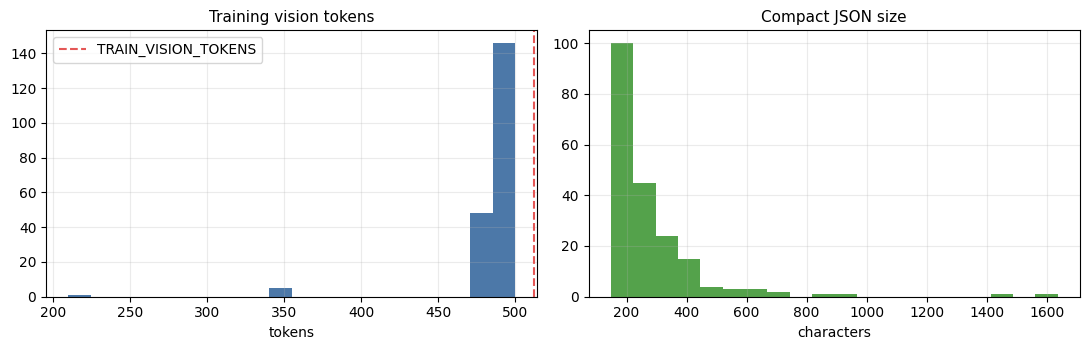

train rows 200 test held out 100
budget: vision ≤ 512 max_seq 3072 ≈ room for JSON tokens 2512
==((====))==  Unsloth 2026.9.12: Fast Qwen2_5_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 2.238 GiB
no_split classes   : ['Qwen2_5_VLDecoderLayer', 'Qwen2_5_VLVisionBlock']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.652 GiB requested
tied to head       : ['model.language_model.embed_tokens']
  cuda:0  budget  12.95 GiB  weights  1.264 GiB  free 11.685 GiB  reserve 11.652 GiB
  cuda:1  budget  12.95 GiB  weights  0.975 GiB  free 11.978 GiB  reserve 11.474 GiB   <-

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

token budget


,max_seq,p50,p95,max,kept,dropped
0,3072,682,853,1265,200,0


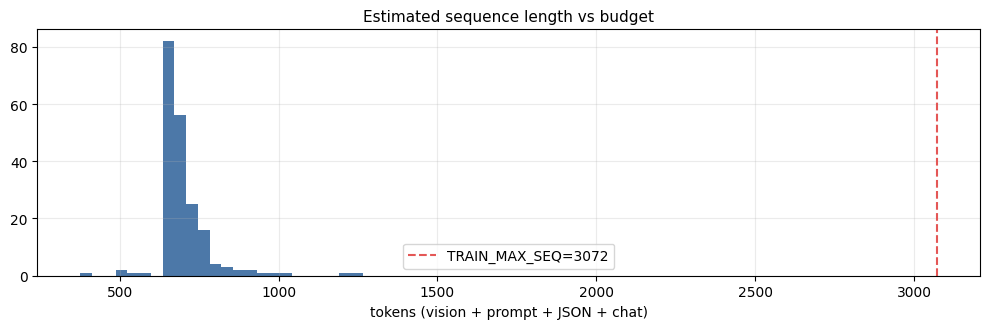

Unsloth: not enough free memory for dataset tokenization workers (~1GB each); tokenizing in-process.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 200 | Num Epochs = 1 | Total steps = 25
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,784,556,544 (0.79% trained)
[unsloth_zoo.log|WARNING]Unsloth: torch.compile hit one of Unsloth's own `torch.compiler.disable`d gradient-checkpointing hooks inside Qwen2_5_VisionPatchEmbed_forward; running it eagerly from here. Training is unaffected apart from speed.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,3.663414
2,3.692835
3,3.809742
4,2.812551
5,3.415788
6,2.792018
7,2.651680
8,1.973139
9,1.897043
10,1.324379


Unsloth: Restored added_tokens_decoder metadata in outputs/lora/checkpoint-5/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/lora/checkpoint-10/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/lora/checkpoint-15/tokenizer_config.json.


skip step 18: non-finite grad (#1)
skip step 19: non-finite grad (#2)


Unsloth: Restored added_tokens_decoder metadata in outputs/lora/checkpoint-20/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/lora/checkpoint-25/tokenizer_config.json.


training log


,step,loss,learning_rate
0,1,3.6634,0.0
1,2,3.6928,0.0
2,3,3.8097,0.0
3,4,2.8126,0.0
4,5,3.4158,0.0
5,6,2.7920,0.0
6,7,2.6517,0.0
7,8,1.9731,0.0
8,9,1.8970,0.0
9,10,1.3244,0.0


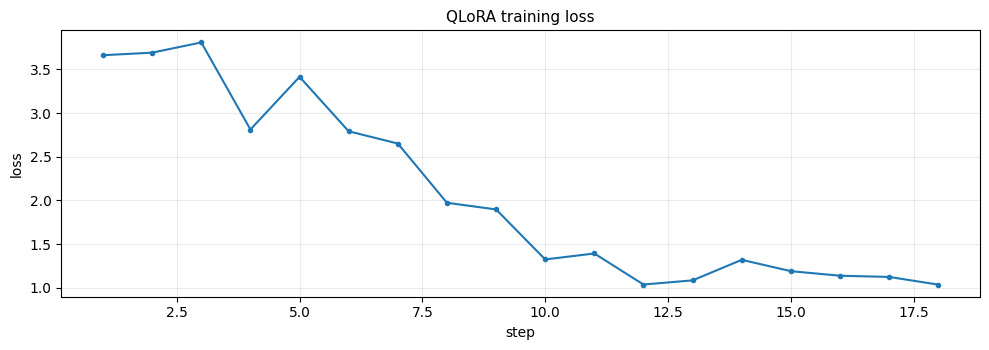

last loss nan last finite step 18
restoring finite adapter from outputs/lora/checkpoint-15


Unsloth: Restored added_tokens_decoder metadata in outputs/lora/tokenizer_config.json.


peak GPU GiB 2.148885726928711


In [17]:
MAX_TRAIN = int(os.environ.get("MAX_TRAIN", "200"))  # 0 = full official train split
CHAT_OVERHEAD = 48  # Qwen chat template / specials, not counting vision tokens


def compact_target(target):
    return json.dumps(target, ensure_ascii=False, separators=(",", ":"))


def to_messages(image, target):
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": EXTRACT_PROMPT},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": compact_target(target)}]},
    ]


def convert_split(split, limit=0):
    rows = []
    vis_counts = []
    json_chars = []
    for row in split:
        image = resize_image(row["image"], TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
        target = cord_to_schema(ground_truth_of(row))
        payload = compact_target(target)
        vis_counts.append(vision_token_count(image))
        json_chars.append(len(payload))
        rows.append({"messages": to_messages(image, target)})
        if limit and len(rows) >= limit:
            break
    if vis_counts:
        stats = pd.DataFrame({
            "vision_tokens": vis_counts,
            "json_chars": json_chars,
        }) if pd is not None else None
        if stats is not None:
            _show_df(stats.describe(percentiles=[0.5, 0.95]).T.round(1), f"resized train images n={len(rows)}")
        if plt is not None:
            _style_plot()
            fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
            axes[0].hist(vis_counts, bins=min(20, max(5, len(vis_counts) // 8)), color="#4C78A8")
            axes[0].axvline(TRAIN_VISION_TOKENS, color="#E45756", linestyle="--", label="TRAIN_VISION_TOKENS")
            axes[0].set_title("Training vision tokens")
            axes[0].set_xlabel("tokens")
            axes[0].legend()
            axes[1].hist(json_chars, bins=min(20, max(5, len(json_chars) // 8)), color="#54A24B")
            axes[1].set_title("Compact JSON size")
            axes[1].set_xlabel("characters")
            fig.tight_layout()
            plt.show()
        else:
            print(
                "resized train images: n", len(rows),
                "vision tokens p50/max", sorted(vis_counts)[len(vis_counts) // 2], max(vis_counts),
                "json chars p50/max", sorted(json_chars)[len(json_chars) // 2], max(json_chars),
            )
    return rows


def estimate_seq_len(tokenizer, row):
    image = row["messages"][0]["content"][0]["image"]
    completion = row["messages"][1]["content"][0]["text"]
    text_ids = tokenizer(EXTRACT_PROMPT + completion, add_special_tokens=False)["input_ids"]
    return vision_token_count(image) + len(text_ids) + CHAT_OVERHEAD


def filter_to_budget(tokenizer, rows, max_seq):
    kept, dropped, lengths = [], 0, []
    for row in rows:
        n = estimate_seq_len(tokenizer, row)
        lengths.append(n)
        if n <= max_seq:
            kept.append(row)
        else:
            dropped += 1
    if lengths:
        ordered = sorted(lengths)
        summary = {
            "max_seq": max_seq,
            "p50": ordered[len(ordered) // 2],
            "p95": ordered[int(len(ordered) * 0.95)],
            "max": ordered[-1],
            "kept": len(kept),
            "dropped": dropped,
        }
        _show_df(pd.DataFrame([summary]) if pd is not None else summary, "token budget")
        if plt is not None:
            _style_plot()
            fig, ax = plt.subplots(figsize=(10, 3.4))
            ax.hist(lengths, bins=min(24, max(6, len(lengths) // 8)), color="#4C78A8")
            ax.axvline(max_seq, color="#E45756", linestyle="--", label=f"TRAIN_MAX_SEQ={max_seq}")
            ax.set_title("Estimated sequence length vs budget")
            ax.set_xlabel("tokens (vision + prompt + JSON + chat)")
            ax.legend()
            fig.tight_layout()
            plt.show()
    if not kept:
        raise RuntimeError(
            "every training row exceeds TRAIN_MAX_SEQ; lower TRAIN_VISION_TOKENS "
            "or raise TRAIN_MAX_SEQ (T4 safe ceiling is about 4096 after free_vlm)"
        )
    return kept



def plot_train_loss(trainer):
    logs = [row for row in getattr(getattr(trainer, "state", None), "log_history", []) or [] if "loss" in row]
    if not logs:
        return
    if pd is not None:
        df = pd.DataFrame(logs)
        cols = [c for c in ("step", "loss", "learning_rate") if c in df.columns]
        _show_df(df[cols].round(4), "training log")
    if plt is None:
        return
    _style_plot()
    steps = [row.get("step", i + 1) for i, row in enumerate(logs)]
    losses = [row["loss"] for row in logs]
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(steps, losses, marker="o", markersize=3)
    ax.set_title("QLoRA training loss")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    fig.tight_layout()
    plt.show()


def _sft_length_kwargs(max_seq):
    import inspect
    from trl import SFTConfig

    params = inspect.signature(SFTConfig.__init__).parameters
    kwargs = {}
    if "max_length" in params:
        kwargs["max_length"] = max_seq
    if "max_seq_length" in params:
        kwargs["max_seq_length"] = max_seq
    return kwargs


def _warmup_steps(n_rows, accum=8):
    return max(5, int(0.2 * max(1, math.ceil(n_rows / accum))))


def _nan_callback():
    from transformers import TrainerCallback

    class GuardNaNCallback(TrainerCallback):
        def __init__(self):
            self.skipped = 0

        def on_pre_optimizer_step(self, args, state, control, model=None, **kwargs):
            if model is None:
                return
            for param in model.parameters():
                if param.grad is not None and not torch.isfinite(param.grad).all():
                    self.skipped += 1
                    print(f"skip step {state.global_step}: non-finite grad (#{self.skipped})")
                    model.zero_grad(set_to_none=True)
                    return

    return GuardNaNCallback()


def _save_finite_adapter(model, processor, trainer, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    logs = [row for row in trainer.state.log_history if "loss" in row]
    last = logs[-1]["loss"] if logs else None
    last_good = 0
    for row in logs:
        if math.isfinite(float(row["loss"])):
            last_good = int(row.get("step", last_good))
    print("last loss", last, "last finite step", last_good)
    if last is not None and not math.isfinite(float(last)):
        ckpts = []
        for path in out_dir.glob("checkpoint-*"):
            try:
                step = int(path.name.split("-")[-1])
            except ValueError:
                continue
            if step <= last_good:
                ckpts.append((step, path))
        if ckpts:
            step, ckpt = max(ckpts)
            print("restoring finite adapter from", ckpt)
            try:
                trainer._load_from_checkpoint(str(ckpt))
            except Exception as exc:
                print("checkpoint reload failed:", exc)
        else:
            print("no finite checkpoint found; saved adapter may be NaN — re-run this cell")
    model.save_pretrained(out_dir)
    processor.save_pretrained(out_dir)


def _bind_processor_pixels(processor, min_pixels, max_pixels):
    # transformers 5.x: min_pixels/max_pixels are read-only properties on
    # Qwen2VLImageProcessor. Setting them raises "_min_pixels has no setter".
    # Training images are already resized; only touch the writable size dict.
    image_processor = getattr(processor, "image_processor", None)
    if image_processor is None:
        return
    size = getattr(image_processor, "size", None)
    if not isinstance(size, dict):
        return
    if "shortest_edge" in size:
        size["shortest_edge"] = min_pixels
    if "longest_edge" in size:
        size["longest_edge"] = max_pixels
    size.pop("min_pixels", None)
    size.pop("max_pixels", None)


def train_unsloth(train_rows):
    from trl import SFTConfig, SFTTrainer
    from unsloth import FastVisionModel
    from unsloth.trainer import UnslothVisionDataCollator

    model, processor = FastVisionModel.from_pretrained(
        MODEL_ID,
        load_in_4bit=True,
        max_seq_length=TRAIN_MAX_SEQ,
        use_gradient_checkpointing="unsloth",
    )
    _bind_processor_pixels(processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
    tokenizer = getattr(processor, "tokenizer", processor)
    train_rows = filter_to_budget(tokenizer, train_rows, TRAIN_MAX_SEQ)
    model = FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers=False,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        use_gradient_checkpointing="unsloth",
        random_state=3407,
    )
    FastVisionModel.for_training(model)
    report = "wandb" if os.environ.get("WANDB_API_KEY") and os.environ.get("WANDB_MODE") != "disabled" else "none"
    collator = UnslothVisionDataCollator(
        model,
        processor,
        max_seq_length=TRAIN_MAX_SEQ,
        resize="max",
        completion_only_loss=True,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=processor,
        data_collator=collator,
        train_dataset=train_rows,
        args=SFTConfig(
            per_device_train_batch_size=1,
            gradient_accumulation_steps=8,
            num_train_epochs=1,
            learning_rate=float(os.environ.get("TRAIN_LR", "5e-5")),
            warmup_steps=_warmup_steps(len(train_rows)),
            max_grad_norm=1.0,
            logging_steps=1,
            optim="adamw_torch",
            weight_decay=0.001,
            lr_scheduler_type="cosine",
            seed=3407,
            output_dir=str(ADAPTER_DIR),
            report_to=report,
            remove_unused_columns=False,
            dataset_text_field="",
            dataset_kwargs={"skip_prepare_dataset": True},
            fp16=True,
            bf16=False,
            dataloader_num_workers=0,
            save_strategy="steps",
            save_steps=5,
            save_total_limit=4,
            logging_nan_inf_filter=False,
            **_sft_length_kwargs(TRAIN_MAX_SEQ),
        ),
        callbacks=[_nan_callback()],
    )
    trainer.train()
    plot_train_loss(trainer)
    _save_finite_adapter(model, processor, trainer, ADAPTER_DIR)
    del trainer, model
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    return ADAPTER_DIR


def train_hf(train_rows):
    import gc
    from peft import LoraConfig, get_peft_model
    from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2_5_VLForConditionalGeneration
    from trl import SFTConfig, SFTTrainer

    # A failed Unsloth attempt already imported unsloth (which patches SFTTrainer)
    # and may still hold the 3B on GPU. Free it first.
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()

    processor = AutoProcessor.from_pretrained(
        HF_BASE_ID, min_pixels=TRAIN_MIN_PIXELS, max_pixels=TRAIN_MAX_PIXELS
    )
    _bind_processor_pixels(processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)
    train_rows = filter_to_budget(processor.tokenizer, train_rows, TRAIN_MAX_SEQ)
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        HF_BASE_ID, quantization_config=quant, device_map="auto", torch_dtype=torch.float16
    )
    model = get_peft_model(
        model,
        LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            bias="none",
            task_type="CAUSAL_LM",
        ),
    )
    report = "wandb" if os.environ.get("WANDB_API_KEY") else "none"
    trainer_kwargs = {"model": model, "train_dataset": train_rows}
    sft_kwargs = dict(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        num_train_epochs=1,
        learning_rate=float(os.environ.get("TRAIN_LR", "5e-5")),
        warmup_steps=_warmup_steps(len(train_rows)),
        max_grad_norm=1.0,
        logging_steps=1,
        output_dir=str(ADAPTER_DIR),
        report_to=report,
        remove_unused_columns=False,
        fp16=True,
        dataloader_num_workers=0,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        save_strategy="steps",
        save_steps=5,
        save_total_limit=4,
        logging_nan_inf_filter=False,
    )
    sft_kwargs.update(_sft_length_kwargs(TRAIN_MAX_SEQ))
    try:
        from unsloth.trainer import UnslothVisionDataCollator

        trainer_kwargs["tokenizer"] = processor
        trainer_kwargs["data_collator"] = UnslothVisionDataCollator(
            model, processor, max_seq_length=TRAIN_MAX_SEQ, resize="max", completion_only_loss=True
        )
    except Exception:
        trainer_kwargs["processing_class"] = processor
    trainer = SFTTrainer(args=SFTConfig(**sft_kwargs), callbacks=[_nan_callback()], **trainer_kwargs)
    trainer.train()
    plot_train_loss(trainer)
    _save_finite_adapter(model, processor, trainer, ADAPTER_DIR)
    del trainer, model
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    return ADAPTER_DIR


trained = False
if HAS_GPU and dataset is not None:
    if vlm.get("model") is not None:
        free_vlm()
    train_rows = convert_split(dataset["train"], MAX_TRAIN)
    print("train rows", len(train_rows), "test held out", len(splits["test"]))
    print(
        "budget: vision ≤", TRAIN_VISION_TOKENS,
        "max_seq", TRAIN_MAX_SEQ,
        "≈ room for JSON tokens", TRAIN_MAX_SEQ - TRAIN_VISION_TOKENS - CHAT_OVERHEAD,
    )
    try:
        train_unsloth(train_rows)
        trained = True
    except Exception as exc:
        print("Unsloth failed, falling back:", type(exc).__name__, exc)
        import gc
        gc.collect()
        if HAS_GPU:
            torch.cuda.empty_cache()
        try:
            train_hf(train_rows)
            trained = True
        except Exception as hf_exc:
            print("HuggingFace training also failed:", type(hf_exc).__name__, hf_exc)
    if HAS_GPU and trained:
        print("peak GPU GiB", torch.cuda.max_memory_allocated() / 1024**3)
else:
    print("skip training — need GPU + CORD")




## 10. Fine-tuned eval, comparison, optional Hub push

Reload the adapter and score the **same** `eval_rows` as zero-shot. The comparison table is the assignment result: line items should rise; tax/total should stay near the zero-shot baseline.


freed eval VLM (required before QLoRA — T4 cannot hold two 3B copies)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

loaded Qwen/Qwen2.5-VL-3B-Instruct adapter outputs/lora
fine-tuned  n=8  receipt_exact=0.000  hallu=0.000  latency_ms p50/p95=40723.51439900012/454459.2700810001  gpu=1.24 GiB


,field,precision,recall,f1,exact_match
0,store_name,0.000,0.000,0.000,0.875
1,date,0.000,0.000,0.000,1.000
2,subtotal,0.714,0.833,0.769,0.625
3,tax,1.000,1.000,1.000,1.000
4,total,0.857,0.750,0.800,0.750
5,line_items.name,0.583,0.500,0.538,0.368
6,line_items.qty,0.500,0.333,0.400,0.526
7,line_items.unit_price,0.000,0.000,0.000,0.895
8,line_items.amount,0.667,0.429,0.522,0.421


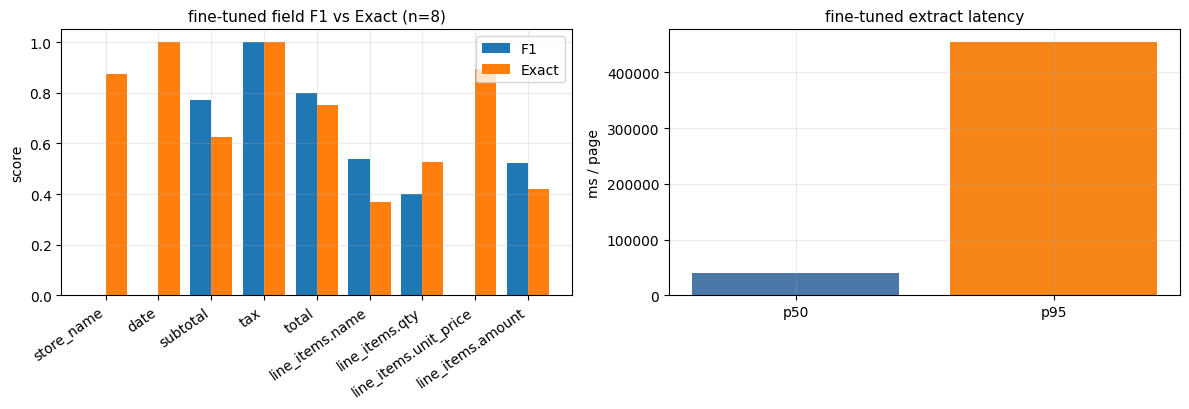

zero-shot  n=8  receipt_exact=0.000  hallu=0.000  latency_ms p50/p95=19031.025934000012/181904.865773  gpu=1.21 GiB


,field,precision,recall,f1,exact_match
0,store_name,0.000,0.000,0.000,0.625
1,date,0.000,0.000,0.000,1.000
2,subtotal,0.714,0.833,0.769,0.625
3,tax,1.000,1.000,1.000,1.000
4,total,1.000,0.875,0.933,0.875
5,line_items.name,0.545,0.429,0.480,0.316
6,line_items.qty,0.273,0.333,0.300,0.263
7,line_items.unit_price,0.000,0.000,0.000,0.474
8,line_items.amount,0.600,0.429,0.500,0.368


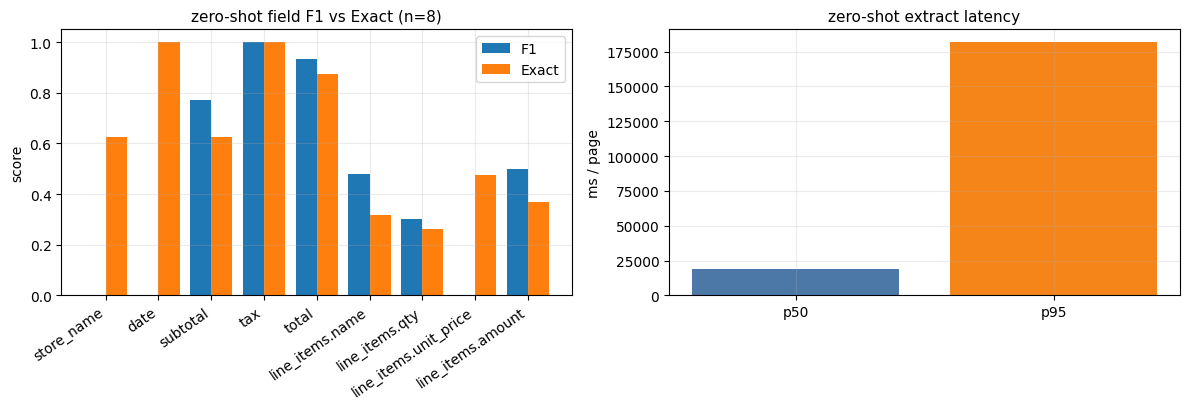

fine-tuned  n=8  receipt_exact=0.000  hallu=0.000  latency_ms p50/p95=40723.51439900012/454459.2700810001  gpu=1.24 GiB


,field,precision,recall,f1,exact_match
0,store_name,0.000,0.000,0.000,0.875
1,date,0.000,0.000,0.000,1.000
2,subtotal,0.714,0.833,0.769,0.625
3,tax,1.000,1.000,1.000,1.000
4,total,0.857,0.750,0.800,0.750
5,line_items.name,0.583,0.500,0.538,0.368
6,line_items.qty,0.500,0.333,0.400,0.526
7,line_items.unit_price,0.000,0.000,0.000,0.895
8,line_items.amount,0.667,0.429,0.522,0.421


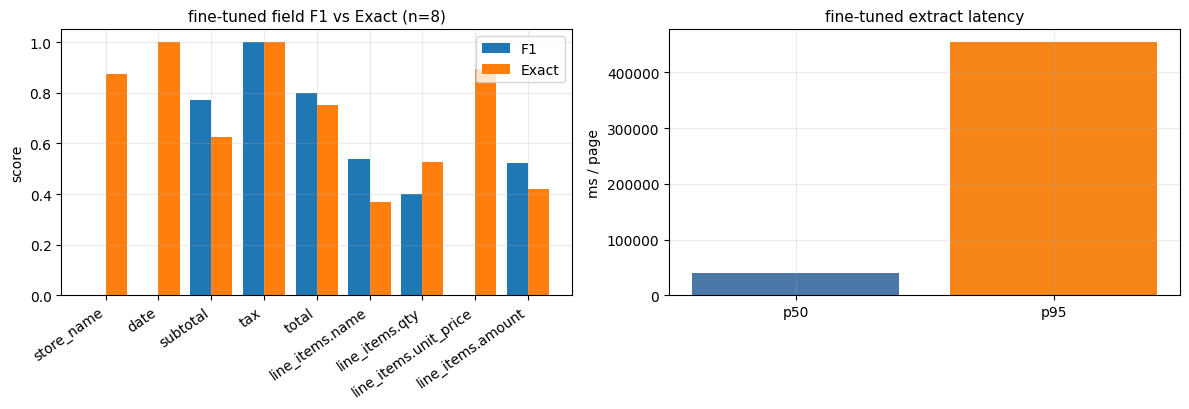

zero-shot vs fine-tuned (same test ids)
CORD gold store_name/date are always null — F1 stays 0; Exact rising means fewer invented headers.
Want line_items.name/qty up without dropping tax/total.


,field,zs_f1,ft_f1,delta_f1,zs_exact,ft_exact,delta_exact
0,store_name,0.000,0.000,0.000,0.625,0.875,0.250
1,date,0.000,0.000,0.000,1.000,1.000,0.000
2,subtotal,0.769,0.769,0.000,0.625,0.625,0.000
3,tax,1.000,1.000,0.000,1.000,1.000,0.000
4,total,0.933,0.800,-0.133,0.875,0.750,-0.125
5,line_items.name,0.480,0.538,0.058,0.316,0.368,0.053
6,line_items.qty,0.300,0.400,0.100,0.263,0.526,0.263
7,line_items.unit_price,0.000,0.000,0.000,0.474,0.895,0.421
8,line_items.amount,0.500,0.522,0.022,0.368,0.421,0.053


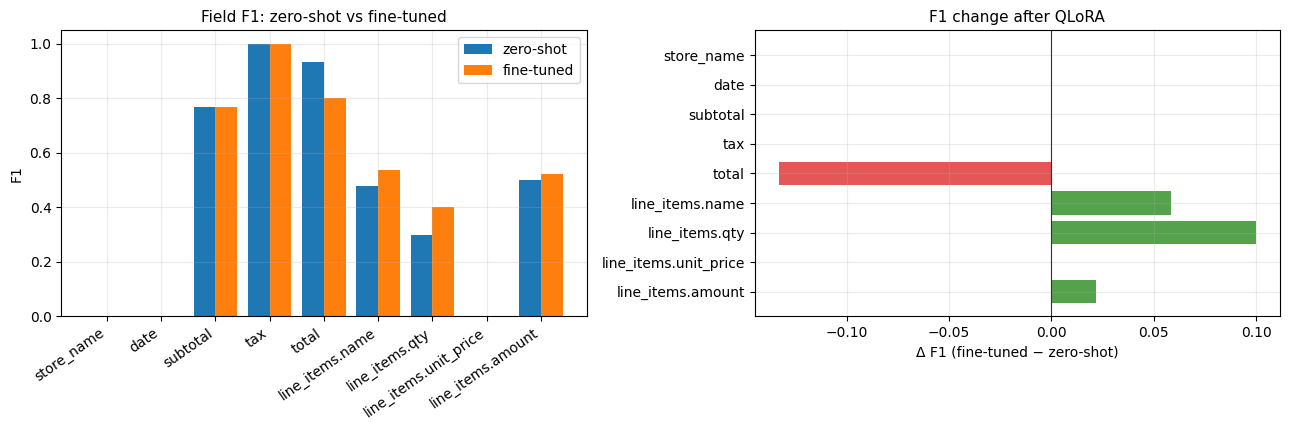

wrote pipeline_out/metrics.json
adapter local at outputs/lora — set HF_PUSH=1 to upload to maheshnallada/vlm-receipt-extraction-lora


In [18]:

def _field_score(stage, name, leaf=None):
    block = stage["fields"][name]
    return (block[leaf] if leaf else block)["f1"], (block[leaf] if leaf else block)["exact_match"]


def compare_stages(zero_shot, fine_tuned):
    if not zero_shot or not fine_tuned:
        print("need both stages to compare")
        return
    pairs = [
        ("store_name", None),
        ("date", None),
        ("subtotal", None),
        ("tax", None),
        ("total", None),
        ("line_items", "name"),
        ("line_items", "qty"),
        ("line_items", "unit_price"),
        ("line_items", "amount"),
    ]
    print("zero-shot vs fine-tuned (same test ids)")
    print("CORD gold store_name/date are always null — F1 stays 0; Exact rising means fewer invented headers.")
    print("Want line_items.name/qty up without dropping tax/total.")
    rows = []
    for name, leaf in pairs:
        zf, ze = _field_score(zero_shot, name, leaf)
        ff, fe = _field_score(fine_tuned, name, leaf)
        rows.append({
            "field": f"{name}.{leaf}" if leaf else name,
            "zs_f1": zf,
            "ft_f1": ff,
            "delta_f1": ff - zf,
            "zs_exact": ze,
            "ft_exact": fe,
            "delta_exact": fe - ze,
        })
    if pd is None:
        print(rows)
        return
    df = pd.DataFrame(rows)
    _show_df(df.round(3))
    if plt is None:
        return
    _style_plot()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    x = range(len(df))
    axes[0].bar([i - 0.2 for i in x], df["zs_f1"], width=0.4, label="zero-shot")
    axes[0].bar([i + 0.2 for i in x], df["ft_f1"], width=0.4, label="fine-tuned")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(df["field"], rotation=35, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1")
    axes[0].set_title("Field F1: zero-shot vs fine-tuned")
    axes[0].legend()
    colors = ["#54A24B" if v >= 0 else "#E45756" for v in df["delta_f1"]]
    axes[1].barh(df["field"][::-1], df["delta_f1"][::-1], color=colors[::-1])
    axes[1].axvline(0, color="#333", linewidth=0.8)
    axes[1].set_xlabel("Δ F1 (fine-tuned − zero-shot)")
    axes[1].set_title("F1 change after QLoRA")
    fig.tight_layout()
    plt.show()


fine_tuned = None
if trained and HAS_GPU:
    free_vlm()
    import gc
    gc.collect()
    if HAS_GPU:
        torch.cuda.empty_cache()
    load_vlm(ADAPTER_DIR)
    fine_tuned = eval_vlm(eval_rows, "fine-tuned")

stages = [s for s in (zero_shot, fine_tuned) if s]
report = {
    "note": "Standalone notebook. Test ids never used in training.",
    "stages": stages,
    "hardware": "T4" if HAS_GPU else "CPU (VLM stages skipped)",
}
payload = json.dumps(report, indent=2)
(WORK / "metrics.json").write_text(payload, encoding="utf-8")
try:
    Path("notebooks").mkdir(exist_ok=True)
    Path("notebooks/metrics.json").write_text(payload, encoding="utf-8")
except Exception:
    pass

for stage in stages:
    show_table(stage)
compare_stages(zero_shot, fine_tuned)
if not stages:
    print("No VLM stages. CPU demo above still ran the full post-process pipeline.")
print("wrote", WORK / "metrics.json")

if os.environ.get("WANDB_API_KEY") and stages:
    try:
        import wandb

        run = wandb.run or wandb.init(project=os.environ.get("WANDB_PROJECT", "vlm-receipt-extraction"))
        table = wandb.Table(columns=["stage", "field", "f1", "exact"])
        for stage in stages:
            for name, scores in stage["fields"].items():
                if name == "line_items":
                    for leaf, leaf_scores in scores.items():
                        table.add_data(stage["stage"], f"line_items.{leaf}", leaf_scores["f1"], leaf_scores["exact_match"])
                else:
                    table.add_data(stage["stage"], name, scores["f1"], scores["exact_match"])
        run.log({"comparison": table})
        wandb.finish()
    except Exception as exc:
        print("wandb log skipped", exc)

if os.environ.get("HF_PUSH") == "1" and ADAPTER_DIR.exists():
    from huggingface_hub import HfApi

    api = HfApi()
    api.create_repo(HF_ADAPTER_REPO, exist_ok=True, private=True)
    api.upload_folder(folder_path=str(ADAPTER_DIR), repo_id=HF_ADAPTER_REPO)
    print("pushed", HF_ADAPTER_REPO)
else:
    print("adapter local at", ADAPTER_DIR, "— set HF_PUSH=1 to upload to", HF_ADAPTER_REPO)
